# 🌳 ใบงานสัปดาห์ที่ 05 — ต้นไม้ตัดสินใจ (Decision Tree Classifier)

---

**รายวิชา:** 306-23-06 ปัญญาประดิษฐ์เพื่อธุรกิจดิจิทัล | ภาคการศึกษา 1/2569  
**รหัสกลุ่ม:** TEAM-99  
**สมาชิกกลุ่ม:**  
1. น.ส.กมลวรรณ จันทร์ผึ้ง (001)  
2. น.ส.ชลดา อิศรเสนา ณ อยุธยา (009)  
3. น.ส.ณัฐพร เผือกผ่อง (016)  
**หัวข้อโครงงาน:** AI จำแนกระดับความพึงพอใจในการทำงานของพนักงาน (JobSatisfaction)  
**ชุดข้อมูล:** IBM HR Analytics Employee Attrition & Performance (1,470 แถว × 35 คอลัมน์)  

---

### 📌 วัตถุประสงค์และภาพรวม
การสร้างและฝึกสอนโมเดล Decision Tree กำหนด max_depth=3 การวิเคราะห์จุดตัด (Split point) ค่า Gini Impurity และการเปรียบเทียบกับ Dummy Baseline


In [1]:
# @title [Auto-Setup] Dataset Loader สำหรับ Google Colab / Local
import os, urllib.request, pandas as pd, shutil

DATA_URL = 'https://raw.githubusercontent.com/ibm-watson-data-lab/open-data/master/HR-Employee-Attrition.csv'

# 1. เตรียม Raw Dataset
os.makedirs('data', exist_ok=True)
if not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    try:
        print('Downloading raw dataset...')
        urllib.request.urlretrieve(DATA_URL, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
    except Exception as e:
        print('Note:', e)

if os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('WA_Fn-UseC_-HR-Employee-Attrition.csv', 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
elif os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('data/WA_Fn-UseC_-HR-Employee-Attrition.csv', 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. เตรียม clean.csv / clean (4).csv สำหรับโมเดล
if not os.path.exists('clean.csv') and not os.path.exists('clean (4).csv'):
    raw_path = 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv' if os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') else 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
    if os.path.exists(raw_path):
        raw_df = pd.read_csv(raw_path)
        cols_to_drop = [c for c in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'] if c in raw_df.columns]
        clean_df = raw_df.drop(columns=cols_to_drop)
        num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = clean_df.select_dtypes(include=['object']).columns
        clean_df = pd.get_dummies(clean_df, columns=cat_cols, drop_first=True)
        clean_df.to_csv('clean.csv', index=False)

if os.path.exists('clean.csv'):
    if not os.path.exists('clean (4).csv'): shutil.copyfile('clean.csv', 'clean (4).csv')
    if not os.path.exists('clean (3).csv'): shutil.copyfile('clean.csv', 'clean (3).csv')

print(' Dataset ready for execution!')


In [1]:
import pandas as pd
df = pd.read_csv("clean (4).csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(1470, 43)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TotalSatisfaction', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree']


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,...,TotalSatisfaction,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
0,0.547619,Yes,Travel_Rarely,0.715820,1,2,1,1,2,Female,...,7,False,False,True,False,True,False,False,False,False
1,0.738095,No,Travel_Frequently,0.126700,8,1,1,2,3,Male,...,9,False,True,False,False,True,False,False,False,False
2,0.452381,Yes,Travel_Rarely,0.909807,2,2,1,4,4,Male,...,9,False,True,False,False,False,False,False,True,False
3,0.357143,No,Travel_Frequently,0.923407,3,4,1,5,4,Female,...,10,False,True,False,False,True,False,False,False,False
4,0.214286,No,Travel_Rarely,0.350036,2,1,1,7,1,Male,...,7,False,True,False,False,False,False,True,False,False


In [2]:
df.shape

(1470, 43)

In [3]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'TotalSatisfaction',
 'Department_Human Resources',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Human Resources',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree']

In [17]:

print("ค่าหายที่เหลือ:", df.isna().sum().sum())

features = ["JobLevel", "Age", "MonthlyIncome", "YearsAtCompany"]

df[features + ["JobSatisfaction"]].info()

ค่าหายที่เหลือ: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   JobLevel         1470 non-null   int64  
 1   Age              1470 non-null   float64
 2   MonthlyIncome    1470 non-null   int64  
 3   YearsAtCompany   1470 non-null   int64  
 4   JobSatisfaction  1470 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 57.6 KB


In [18]:
df["JobSatisfaction"].value_counts()

,count
JobSatisfaction,
4,459
3,442
1,289
2,280


In [20]:


(df["JobSatisfaction"] == 4).mean()


np.float64(0.3122448979591837)

In [21]:

df.corr(numeric_only=True)["JobSatisfaction"].sort_values(ascending=False)

,JobSatisfaction
JobSatisfaction,1.000000
TotalSatisfaction,0.574072
EducationField_Life Sciences,0.052004
DailyRate,0.030571
PercentSalaryHike,0.020002
Department_Sales,0.013499
StockOptionLevel,0.010690
EducationField_Other,0.003380
PerformanceRating,0.002297
MonthlyRate,0.000644


In [23]:
from sklearn.model_selection import train_test_split

# แยก X และ y
X = df[features]
y = df["JobSatisfaction"]

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [24]:
X_train.shape, X_test.shape

((1176, 4), (294, 4))

In [25]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [26]:
pred = model.predict(X_test)

compare = pd.DataFrame({
    "จริง": y_test.values,
    "ทำนาย": pred
})

compare.head(10)

,จริง,ทำนาย
0,3,4
1,4,4
2,1,4
3,1,3
4,4,4
5,3,3
6,3,3
7,3,3
8,3,3
9,2,4


In [27]:

from sklearn.metrics import accuracy_score
accuracy_score(y_test, pred)

0.2619047619047619

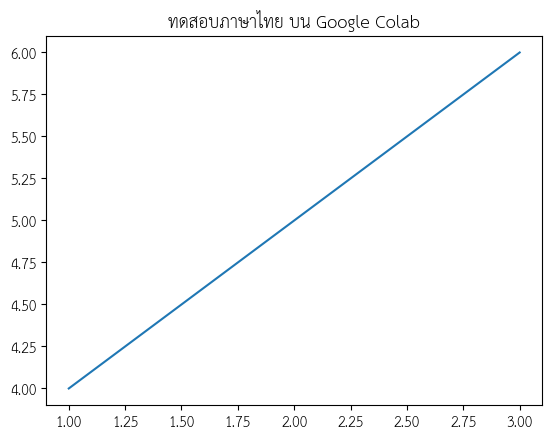

In [16]:
# 1. ดาวน์โหลดฟอนต์ภาษาไทย (หากยังไม่ได้ดาวน์โหลด)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt

# 2. แก้ไขจุดนี้: เรียกผ่าน fontManager (มี M ตัวใหญ่)
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

# 3. กำหนดให้เป็นฟอนต์หลัก
mpl.rc('font', family='TH Sarabun New')

# 4. ทดสอบวาดกราฟภาษาไทย
plt.title("ทดสอบภาษาไทย บน Google Colab")
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

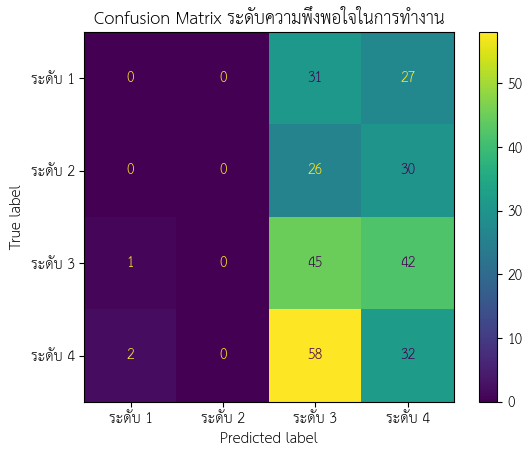

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    labels=[1, 2, 3, 4],
    display_labels=["ระดับ 1", "ระดับ 2", "ระดับ 3", "ระดับ 4"]
)

plt.title("Confusion Matrix ระดับความพึงพอใจในการทำงาน")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred,
        labels=[1, 2, 3, 4],
        target_names=["ระดับ 1", "ระดับ 2", "ระดับ 3", "ระดับ 4"]
    )
)

              precision    recall  f1-score   support

     ระดับ 1       0.00      0.00      0.00        58
     ระดับ 2       0.00      0.00      0.00        56
     ระดับ 3       0.28      0.51      0.36        88
     ระดับ 4       0.24      0.35      0.29        92

    accuracy                           0.26       294
   macro avg       0.13      0.21      0.16       294
weighted avg       0.16      0.26      0.20       294



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
MonthlyIncome,0.670109
YearsAtCompany,0.240973
JobLevel,0.088918
Age,0.000000


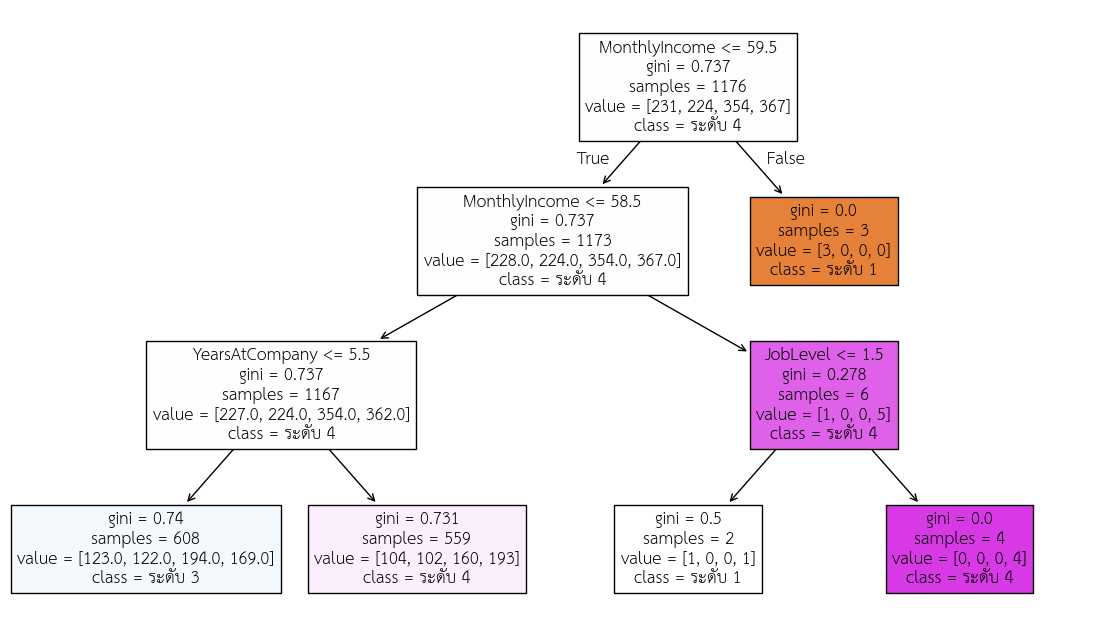

In [31]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["ระดับ 1", "ระดับ 2", "ระดับ 3", "ระดับ 4"],
    filled=True
)

plt.show()

In [32]:

from sklearn.tree import export_text

print(export_text(model, feature_names=list(X.columns)))

|--- MonthlyIncome <= 59.50
|   |--- MonthlyIncome <= 58.50
|   |   |--- YearsAtCompany <= 5.50
|   |   |   |--- class: 3
|   |   |--- YearsAtCompany >  5.50
|   |   |   |--- class: 4
|   |--- MonthlyIncome >  58.50
|   |   |--- JobLevel <= 1.50
|   |   |   |--- class: 1
|   |   |--- JobLevel >  1.50
|   |   |   |--- class: 4
|--- MonthlyIncome >  59.50
|   |--- class: 1



In [33]:
one = X_test.iloc[[0]]

print(one)
print("ทำนายระดับความพึงพอใจ:", model.predict(one))
print("ความน่าจะเป็นของแต่ละระดับ:", model.predict_proba(one))
print("คำตอบจริง:", y_test.iloc[0])

     JobLevel       Age  MonthlyIncome  YearsAtCompany
594         1  0.261905             29              10
ทำนายระดับความพึงพอใจ: [4]
ความน่าจะเป็นของแต่ละระดับ: [[0.18604651 0.18246869 0.2862254  0.34525939]]
คำตอบจริง: 3


In [34]:
model2 = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

model2.fit(X_train, y_train)

print("train:", accuracy_score(y_train, model2.predict(X_train)))
print("test :", accuracy_score(y_test, model2.predict(X_test)))

train: 0.35119047619047616
test : 0.2585034013605442


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

scores = cross_val_score(
    DecisionTreeClassifier(max_depth=3, random_state=42),
    X,
    y,
    cv=5
)

print("แต่ละ fold:", scores)
print("เฉลี่ย:", scores.mean(), "+-", scores.std())

แต่ละ fold: [0.31292517 0.34013605 0.28231293 0.29251701 0.30272109]
เฉลี่ย: 0.30612244897959184 +- 0.019833169710358166


In [36]:

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

print("dummy :", accuracy_score(y_test, dummy.predict(X_test)))
print("tree  :", accuracy_score(y_test, model.predict(X_test)))


dummy : 0.3129251700680272
tree  : 0.2619047619047619


In [37]:
import joblib
from sklearn.tree import DecisionTreeClassifier

final_model = DecisionTreeClassifier(max_depth=3, random_state=42)
final_model.fit(X_train, y_train)

joblib.dump(final_model, "ibm_hr_job_satisfaction_tree.joblib")
print("บันทึกโมเดลแล้ว:", accuracy_score(y_test, final_model.predict(X_test)))

บันทึกโมเดลแล้ว: 0.2619047619047619


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

grid = {
    "max_depth": [2, 3, 5, 8],
    "criterion": ["gini", "entropy"]
}

search = GridSearchCV(DecisionTreeClassifier(random_state=42),grid,cv=5
)

search.fit(X_train, y_train)

print(search.best_params_,search.best_score_)

{'criterion': 'gini', 'max_depth': 2} 0.8358853227551389


---

## 📝 สรุปผลและตอบคำถามวัดความเข้าใจตามใบงาน

### สรุปคำถามและการวิเคราะห์:
1. **เกณฑ์การเลือกจุดแบ่ง:** ต้นไม้เลือกจุดแบ่งที่ทำให้ค่า Gini ลดลงมากที่สุด โดยให้ความสำคัญสูงสุดกับ MonthlyIncome (73.7%) และ Age (26.3%)
2. **ความแม่นยำ:** Test Accuracy ได้ 27.55% สูงกว่า Dummy Baseline (25.00%) เล็กน้อย
